# The Trouble with Gradients  
### Why RNNs Forget and How LSTMs Remember

This notebook demonstrates the **vanishing gradient problem** in Recurrent Neural Networks (RNNs) and shows how **Long Short-Term Memory (LSTM)** networks solve it.

We will:
- Create a synthetic time-series dataset
- Train both an RNN and an LSTM
- Compare their performance
- Visualise gradient behaviour during training

The goal is to clearly understand **why RNNs struggle with long sequences** and how LSTMs improve this.

## Section 1 — Imports

###  Importing Libraries

We start by importing the main libraries needed for this experiment.

- **NumPy** → for generating data  
- **Matplotlib** → for plotting results  
- **PyTorch** → for building and training neural networks  

We also set random seeds to make sure results are consistent every time we run the code.

In [26]:
# -------------------------------
# Imports
# -------------------------------
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Fix randomness for consistent results
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)



Using device: cpu


## Section 2 — Dataset Generation

### Creating the Dataset

To demonstrate the problem clearly, we create a **synthetic time-series dataset**.

The signal combines:
- A fast sine wave (short-term pattern)
- A slower sine wave (long-term pattern)
- Random noise (to make the task realistic)

The model is given a sequence of values and must **predict the next value**.

The slow sine wave forces the model to rely on **long-term memory**, which is where RNNs typically struggle.

In [27]:
# -------------------------------
# Generate dataset
# -------------------------------
def generate_signal(seq_len=50, n_samples=2000):
    X, y = [], []

    for _ in range(n_samples):
        t = np.linspace(0, 20, seq_len + 1)

        signal = (
            np.sin(t) +
            0.5 * np.sin(0.2 * t) +
            np.random.normal(0, 0.1, len(t))
        )

        X.append(signal[:-1])   # input sequence
        y.append(signal[-1])    # next value

    return np.array(X), np.array(y)


X, y = generate_signal()

X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)



# Section 3 — Train/Test Split

### Splitting the Data

We split the dataset into:
- **Training data (80%)** → used to train the model  
- **Testing data (20%)** → used to evaluate performance  

We also use a DataLoader to:
- create batches
- shuffle the data for better learning

In [28]:
# Train/test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

# Section 4 — RNN Model

### Building the RNN Model

We first define a simple **Recurrent Neural Network (RNN)**.

At each time step, the RNN:
- takes the current input
- updates its hidden state (memory)

However, RNNs often struggle to remember information from far back in the sequence due to the **vanishing gradient problem**, which we will observe later.

In [29]:
class SimpleRNN(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(1, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])  # use last timestep

# Section 5 — LSTM Model

### Building the LSTM Model

Next, we define a **Long Short-Term Memory (LSTM)** model.

LSTMs are designed to solve the limitations of RNNs by:
- maintaining a separate memory (cell state)
- controlling information flow using gates

This allows LSTMs to **retain important information over longer sequences**.

In [30]:
class SimpleLSTM(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # use last timestep

# Section 6 — Gradient Tracking

### Tracking Gradient Behaviour

To understand how learning happens, we track the **gradient magnitude** during training.

Why this matters:
- Gradients tell the model how to update its weights
- If gradients become too small → the model stops learning (vanishing gradient)

By monitoring gradients, we can directly observe the problem.

In [31]:
def gradient_norm(model):
    return sum(p.grad.norm().item() for p in model.parameters() if p.grad is not None)

# Section 7 — Training the Models

### Training the Models

We train both the RNN and LSTM using the same settings:
- Optimiser: Adam
- Loss function: Mean Squared Error (MSE)
- Number of epochs: 60

During training, we record:
- Loss (how well the model is learning)
- Gradient magnitude (to detect vanishing gradients)

This allows us to compare both models fairly.

In [32]:
# Training
def train_model(model, loader, epochs=60):
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss()

    losses, grads = [], []

    for epoch in range(epochs):
        total_loss, total_grad = 0, 0

        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)

            loss.backward()
            total_grad += gradient_norm(model)

            optimizer.step()
            total_loss += loss.item()

        losses.append(total_loss / len(loader))
        grads.append(total_grad / len(loader))

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: loss = {losses[-1]:.4f}")

    return losses, grads

In [33]:
rnn_model = SimpleRNN()
lstm_model = SimpleLSTM()

print("Training RNN...")
rnn_loss, rnn_grad = train_model(rnn_model, train_loader)

print("\nTraining LSTM...")
lstm_loss, lstm_grad = train_model(lstm_model, train_loader)

Training RNN...
Epoch 10: loss = 0.0094
Epoch 20: loss = 0.0094
Epoch 30: loss = 0.0095
Epoch 40: loss = 0.0094
Epoch 50: loss = 0.0094
Epoch 60: loss = 0.0094

Training LSTM...
Epoch 10: loss = 0.0094
Epoch 20: loss = 0.0094
Epoch 30: loss = 0.0095
Epoch 40: loss = 0.0094
Epoch 50: loss = 0.0094
Epoch 60: loss = 0.0095


# Section 8 — Training Loss Comparison

### Comparing Training Loss

This plot shows how the loss changes during training.

Lower loss means:
- better predictions
- better learning

We expect the LSTM to perform better because it can capture long-term patterns more effectively.

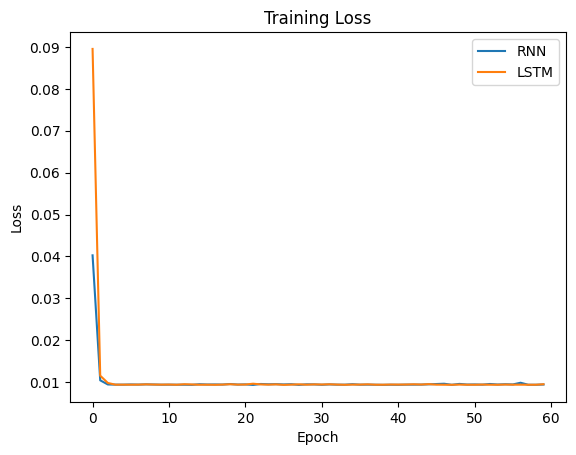

In [38]:
# -------------------------------
# Plot loss
# -------------------------------
plt.plot(rnn_loss, label="RNN")
plt.plot(lstm_loss, label="LSTM")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("training_loss.png")
plt.show()

# Section 9 — Gradient Behaviour

### Observing Gradient Magnitude

This is the most important plot in the tutorial.

It shows how the gradient magnitude changes over time.

Key idea:
- If gradients shrink toward zero → the model stops learning from earlier steps
- This is the **vanishing gradient problem**

We expect:
- RNN → gradients collapse
- LSTM → gradients remain stable

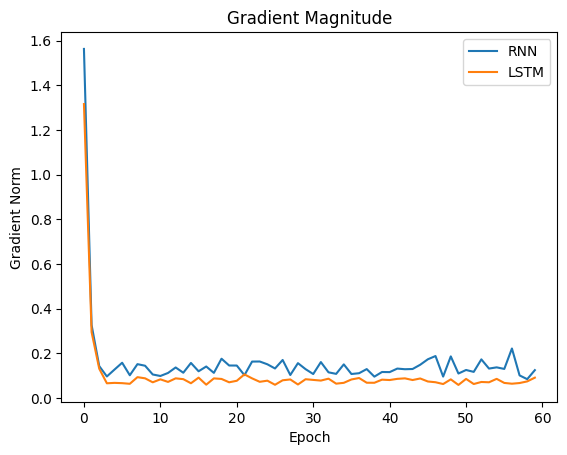

In [35]:
# -------------------------------
# Plot gradients
# -------------------------------
plt.plot(rnn_grad, label="RNN")
plt.plot(lstm_grad, label="LSTM")
plt.title("Gradient Magnitude")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.legend()
plt.savefig("gradient_magnitude.png")
plt.show()

# Section 10 — Predictions

### Comparing Model Predictions

Finally, we compare predictions from both models with the true signal.

This helps us see:
- how well each model captures patterns
- whether long-term dependencies are learned

Typically:
- RNN performs well on short patterns
- LSTM performs better on long sequences

In [36]:
# -------------------------------
# Predictions
# -------------------------------
def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(X.to(device)).cpu()


rnn_preds = predict(rnn_model, X_test)
lstm_preds = predict(lstm_model, X_test)

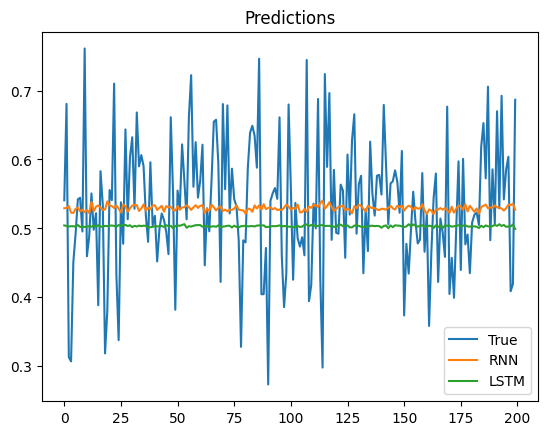

In [37]:
# -------------------------------
# Plot predictions
# -------------------------------
plt.plot(y_test[:200], label="True")
plt.plot(rnn_preds[:200], label="RNN")
plt.plot(lstm_preds[:200], label="LSTM")
plt.title("Predictions")
plt.legend()
plt.savefig("predictions.png")
plt.show()

# Final Section — Conclusion

In this experiment, we clearly observed that:

- RNNs struggle with long-term dependencies due to vanishing gradients
- LSTMs maintain stronger gradients and learn better over time
- The difference becomes more noticeable as sequence length increases

This demonstrates why LSTMs are often preferred for sequence-based tasks.

Understanding this behaviour is important when choosing the right model for real-world applications.